<a href="https://colab.research.google.com/github/swirita/Adult-Income-Prediction/blob/main/Adult_Income_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Adult Income Prediction

* **Author**: Siwar Ehwass

## Overview

### Context

This dataset comes from the 1994 US Census, collected by the UCI Machine Learning Repository. It is a widely cited **KNN dataset**, often used as a starting point for data pre-processing and machine learning practice. Each row is one person, and the goal is to predict whether their annual income is <=50K or >50K.

### Dataset Overview

**Target**

- `Income` — binary target: <=50K or >50K.

**Features**

- 14 attributes describing a person's demographics and work history (age, education, occupation, hours worked, marital status, etc.).
- The dataset has **48,842 rows** and **16 columns** in total (14 features + 1 target + 1 duplicate `education-num` column some versions include).

**Expected Challenges**

- Missing values are coded as `?` in columns like `workclass`, `occupation`, and `native-country`, so they need to be handled before modeling.
- The target is imbalanced — most people ear<=50Kso accuracy alone won't tell the full story.
- Mixed data types: numeric (age, hours-per-week) and categorical (education, marital-status) need different preprocessing.
- `fnlwgt` is a survey weight, not a real feature — it shouldn't be used for prediction.



Liu, W. (October 2016). Adult Income Dataset. Retrieved Aug. 7, 2026. [Dataset](https://www.kaggle.com/datasets/wenruliu/adult-income-dataset).

The detailed description on the dataset can be found in the original UCI [documentation](http://www.cs.toronto.edu/~delve/data/adult/adultDetail.html).


Becker, B. & Kohavi, R. (1996). UCI Machine Learning Repository. [Source](https://doi.org/10.24432/C5XW20).




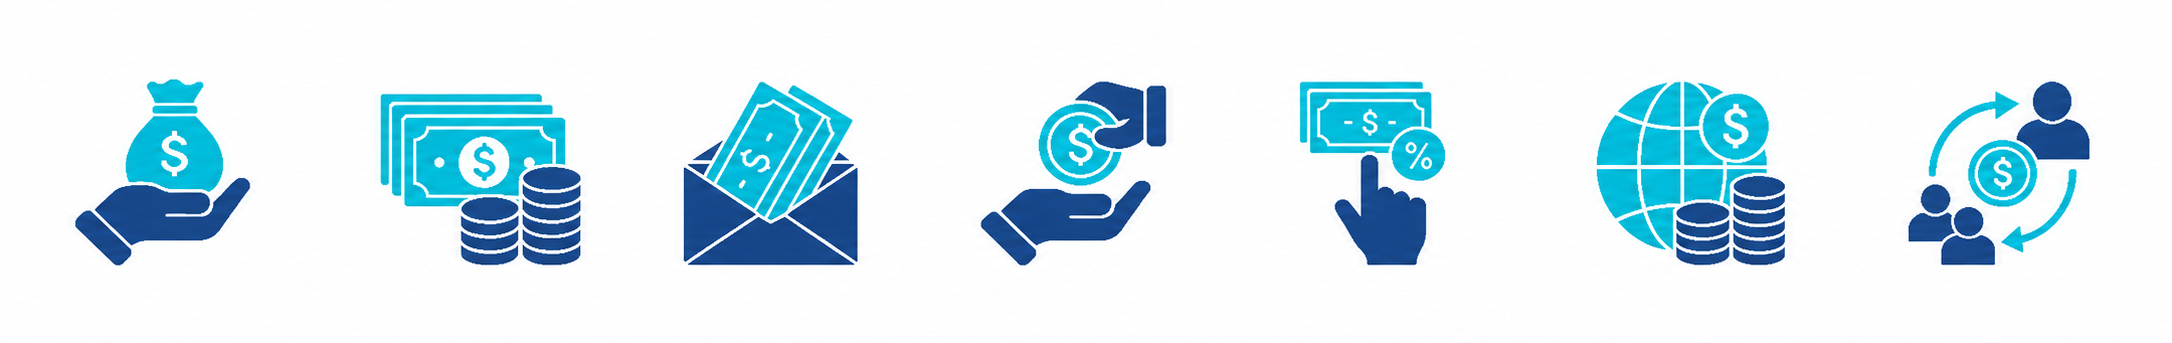

## Data Dictionary

| Column | Description |
|---|---|
| `age` | Age of the person |
| `workclass` | Type of employment |
| `fnlwgt` | Census weight assigned to the person |
| `education` | Highest education level |
| `educational-num` | Numerical representation of education level |
| `marital-status` | Marital status |
| `occupation` | Type of job |
| `relationship` | Relationship role in the household |
| `race` | Race category |
| `gender` | Gender of the person |
| `capital-gain` | Money gained from investments |
| `capital-loss` | Money lost from investments |
| `hours-per-week` | Number of working hours per week |
| `native-country` | Country of origin |
| `income` | Target: whether income is `<=50K` or `>50K` |

## Imports

In [59]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("wenruliu/adult-income-dataset")

print("Path to dataset files:", path)

import os
print(os.listdir("/kaggle/input/adult-income-dataset"))

Using Colab cache for faster access to the 'adult-income-dataset' dataset.
Path to dataset files: /kaggle/input/adult-income-dataset
['adult.csv']


In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# sklearn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, LabelEncoder, LabelBinarizer, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, silhouette_score, precision_recall_fscore_support

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.inspection import permutation_importance
from sklearn.cluster import KMeans
from sklearn.feature_selection import SequentialFeatureSelector
from imblearn.pipeline import make_pipeline as imb_make_pipeline
from imblearn.over_sampling import SMOTE
from sklearn.base import clone
from sklearn.utils.class_weight import compute_class_weight

from sklearn import set_config
set_config(transform_output='pandas')

## Load & Inspect Data

In [61]:
# create dataframe
df = pd.read_csv("/kaggle/input/adult-income-dataset/adult.csv")
# check information about df
df.info()
# check first 5 rows
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


Observations

- The dataset has **48,842 rows** and **15 columns**.
- It contains **6 numerical** and **9 categorical** columns.
- `income` is the target with two classes: `<=50K` and `>50K`.
- Some missing values are stored as `?`.


## Data Cleaning & Feature Inspection

In [62]:
# check for duplicated data
print(f'\nbefore: {df.duplicated().sum()}')

# drop dupes
df= df.drop_duplicates()

# check again
print(f'\nafter: {df.duplicated().sum()}')


before: 52

after: 0


In [63]:
# check for unique percentage
df.nunique() / len(df) * 100

,0
age,0.151670
workclass,0.018446
fnlwgt,58.460750
education,0.032794
educational-num,0.032794
marital-status,0.014347
occupation,0.030744
relationship,0.012298
race,0.010248
gender,0.004099


In [64]:
# filter out both num and object features
num_cols=df.select_dtypes('number').columns # select numbers
cat_cols=df.select_dtypes('object').columns # select objects

# loop through each one's value counts (objects)
for col in cat_cols:
    print(f'Value counts of {col}:\n {df[col].value_counts(dropna=False)} \n')

Value counts of workclass:
 workclass
Private             33860
Self-emp-not-inc     3861
Local-gov            3136
?                    2795
State-gov            1981
Self-emp-inc         1694
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64 

Value counts of education:
 education
HS-grad         15770
Some-college    10863
Bachelors        8013
Masters          2656
Assoc-voc        2060
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           954
Prof-school       834
9th               756
12th              655
Doctorate         594
5th-6th           507
1st-4th           245
Preschool          81
Name: count, dtype: int64 

Value counts of marital-status:
 marital-status
Married-civ-spouse       22366
Never-married            16082
Divorced                  6630
Separated                 1530
Widowed                   1518
Married-spouse-absent      627
Married-AF-spouse           37
Name: count, dtyp

In [65]:
# handling missing values
df= df.replace('?', np.nan)

In [66]:
# handling native-country
df['native-country'] = df['native-country'].replace({
    'Holand-Netherlands': 'Netherlands',
    'Trinadad&Tobago': 'Trinidad&Tobago',
    'Columbia': 'Colombia'
})

In [67]:
# check describe for numbers (loop)
for col in num_cols:
    print(f'Describe for {col}\n {df[col].describe()}')

Describe for age
 count    48790.000000
mean        38.652798
std         13.708493
min         17.000000
25%         28.000000
50%         37.000000
75%         48.000000
max         90.000000
Name: age, dtype: float64
Describe for fnlwgt
 count    4.879000e+04
mean     1.896690e+05
std      1.056172e+05
min      1.228500e+04
25%      1.175550e+05
50%      1.781385e+05
75%      2.376062e+05
max      1.490400e+06
Name: fnlwgt, dtype: float64
Describe for educational-num
 count    48790.000000
mean        10.078807
std          2.570046
min          1.000000
25%          9.000000
50%         10.000000
75%         12.000000
max         16.000000
Name: educational-num, dtype: float64
Describe for capital-gain
 count    48790.000000
mean      1080.217688
std       7455.905921
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      99999.000000
Name: capital-gain, dtype: float64
Describe for capital-loss
 count    48790.000000
mean        87.595573
s

## Missing Values

In [68]:
# see columns and rows where NaN is present in df
df.isna().sum()

,0
age,0
workclass,2795
fnlwgt,0
education,0
educational-num,0
marital-status,0
occupation,2805
relationship,0
race,0
gender,0


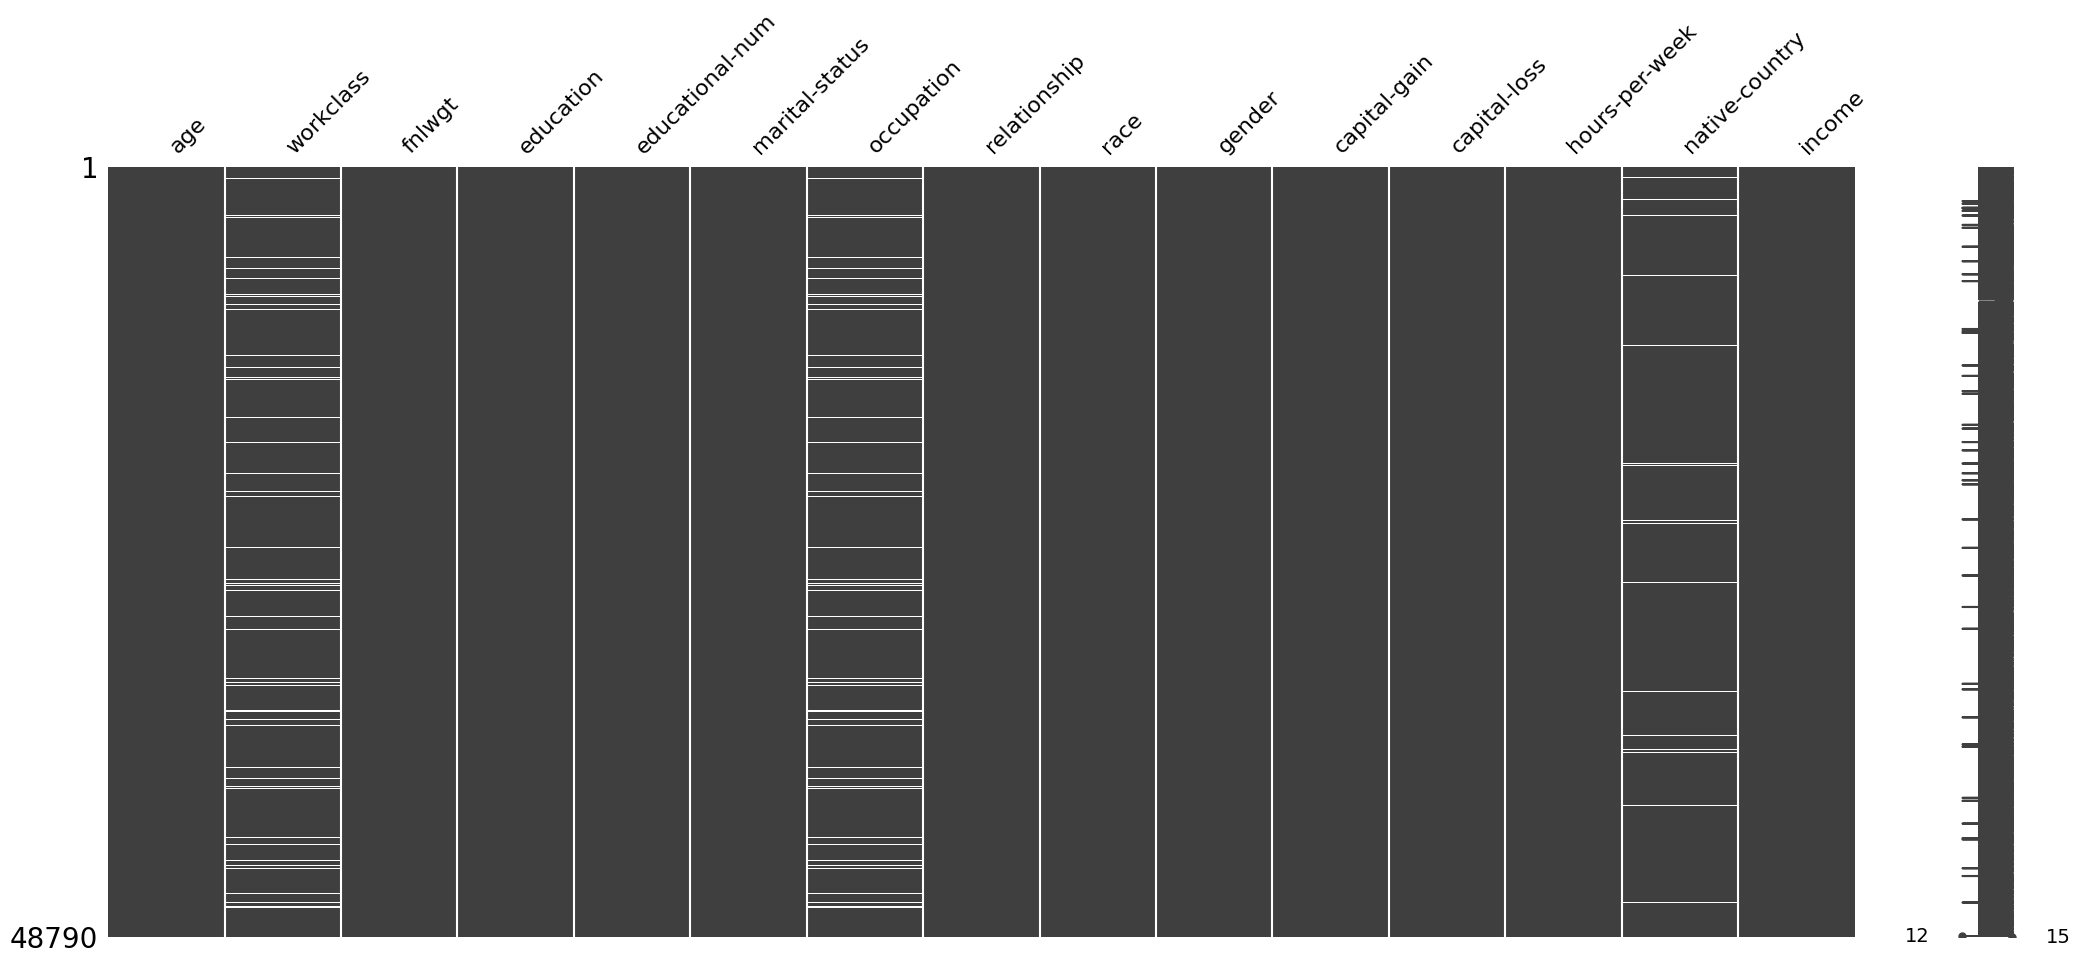

In [69]:
msno.matrix(df);

- workclass and occupation contain missing values of about the same pattern, which makes sense because if you dont know someones occupation itll make sense that you dont know their workclass as well, and vise versa

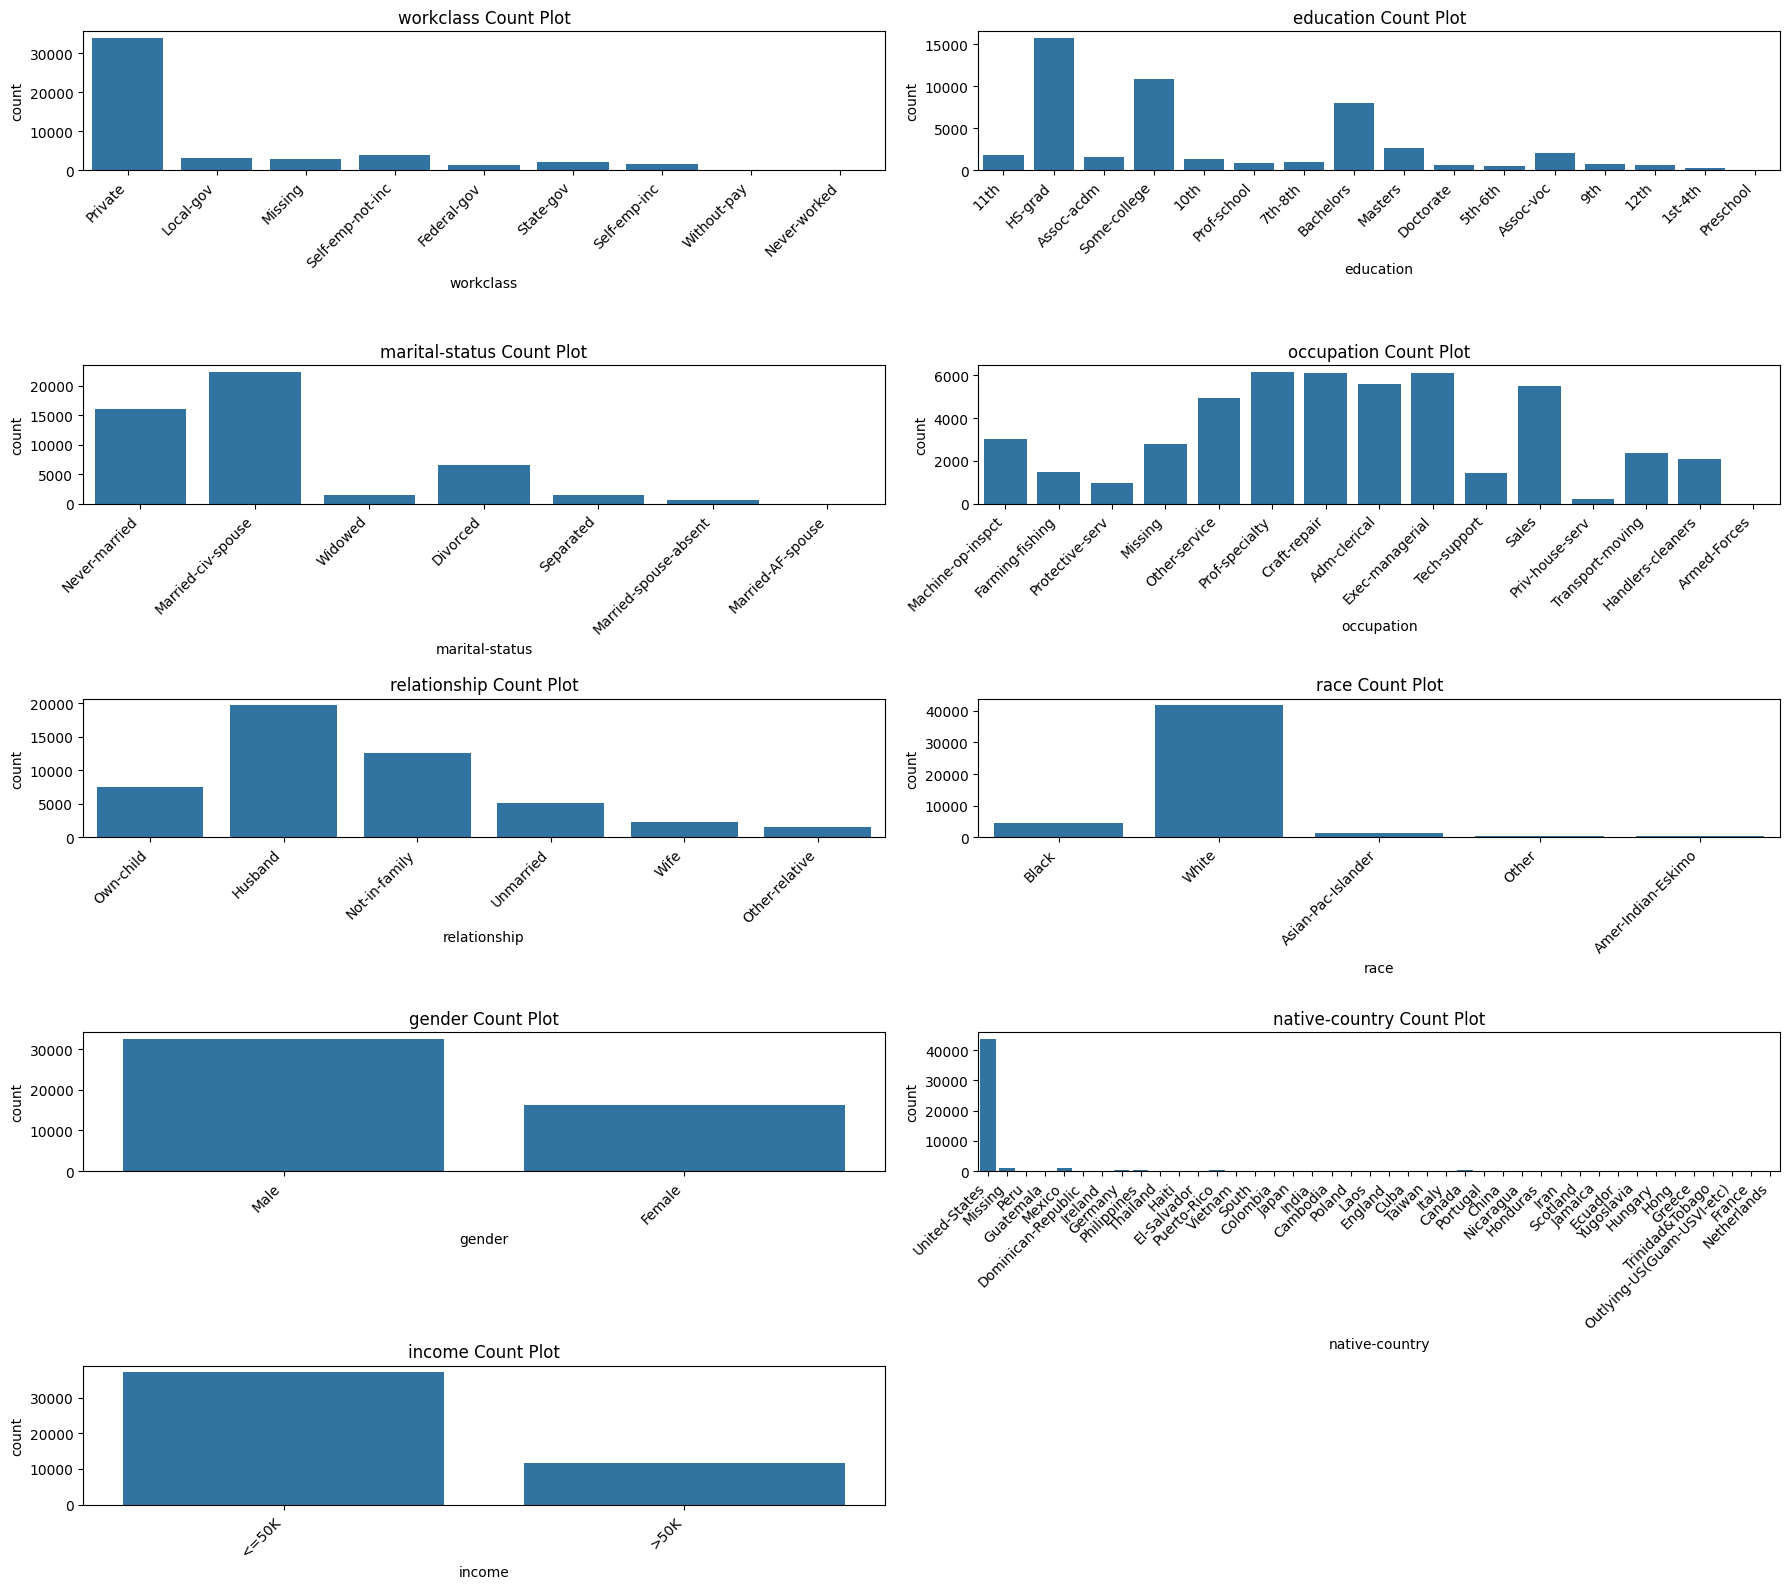

In [70]:
fig, axes = plt.subplots(5, 2, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(cat_cols):

    # Temporary copy for visualization only
    temp = df[col].fillna("Missing")

    sns.countplot(x=temp, ax=axes[i])

    axes[i].set_title(f"{col} Count Plot")
    axes[i].set_xlabel(col)

    # Rotate ticks and align right
    axes[i].tick_params(axis='x', rotation=45)

    for label in axes[i].get_xticklabels():
        label.set_horizontalalignment('right')

# Remove the extra empty subplot
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

 Insights

- `workclass` is mostly **Private**.
- `education` is mostly **HS-grad**, **Some-college**, and **Bachelors**.
- `marital-status` is mostly **Married-civ-spouse** and **Never-married**.
- `race` is mostly **White**.
- There are more **Male** records than **Female**.
- `native-country` is mostly **United-States**.
- `income` is imbalanced, with more `<=50K` records.

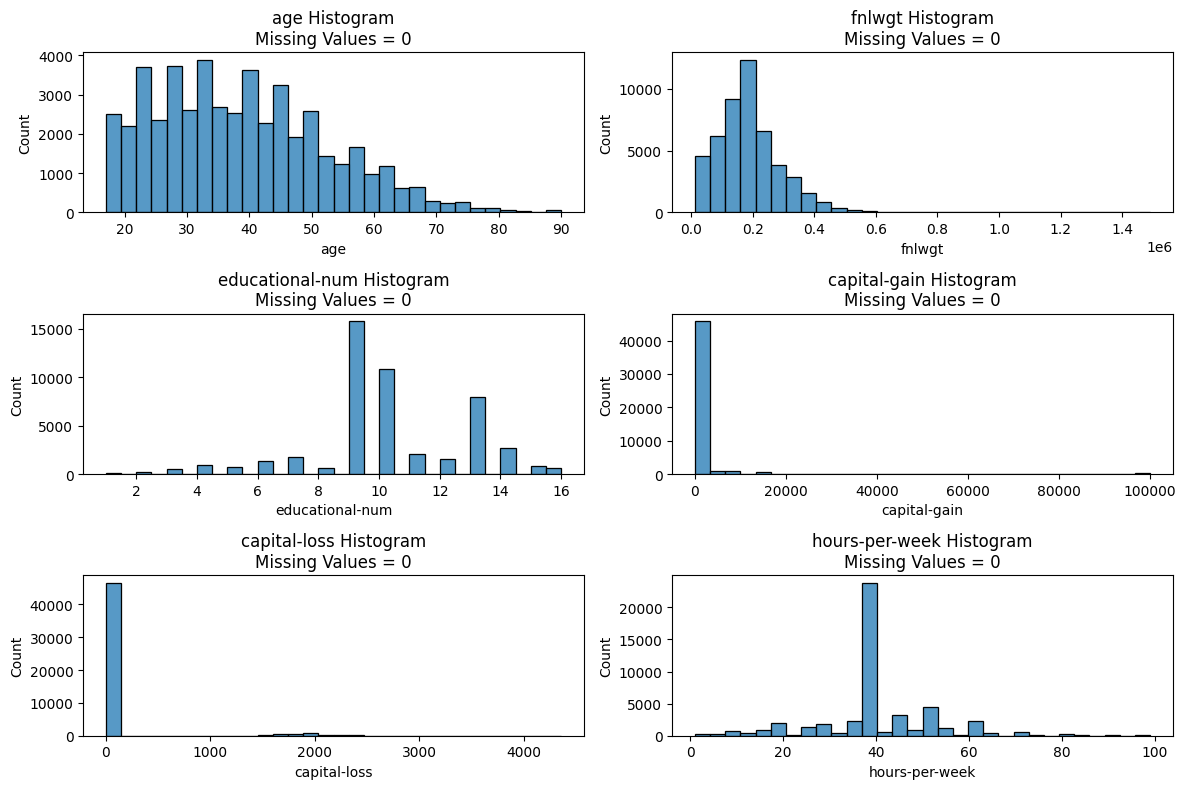

In [71]:
fig, axes = plt.subplots(3, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):

    missing = df[col].isna().sum()

    sns.histplot(data=df, x=col, bins=30, ax=axes[i])

    axes[i].set_title(f"{col} Histogram\nMissing Values = {missing}")

plt.tight_layout()

- `age` is mostly between about **20 and 50**.
- `fnlwgt` is right-skewed with some large values.
- `capital-gain` and `capital-loss` are mostly **0**.
- `hours-per-week` is mostly around **40 hours**.
- There are no missing values in numerical columns.

## Exploratry Data Analysis

In [72]:
target = 'income'

categorical_cols = [
    'workclass',
    'marital-status',
    'occupation',
    'relationship',
    'race',
    'gender',
    'native-country'
]

ordinal_cols = [
    'education',
    'educational-num'
]

numerical_cols = [
    'age',
    'fnlwgt',
    'capital-gain',
    'capital-loss',
    'hours-per-week'
]

In [73]:
df[target].value_counts(normalize=True)

,proportion
income,
<=50K,0.760586
>50K,0.239414


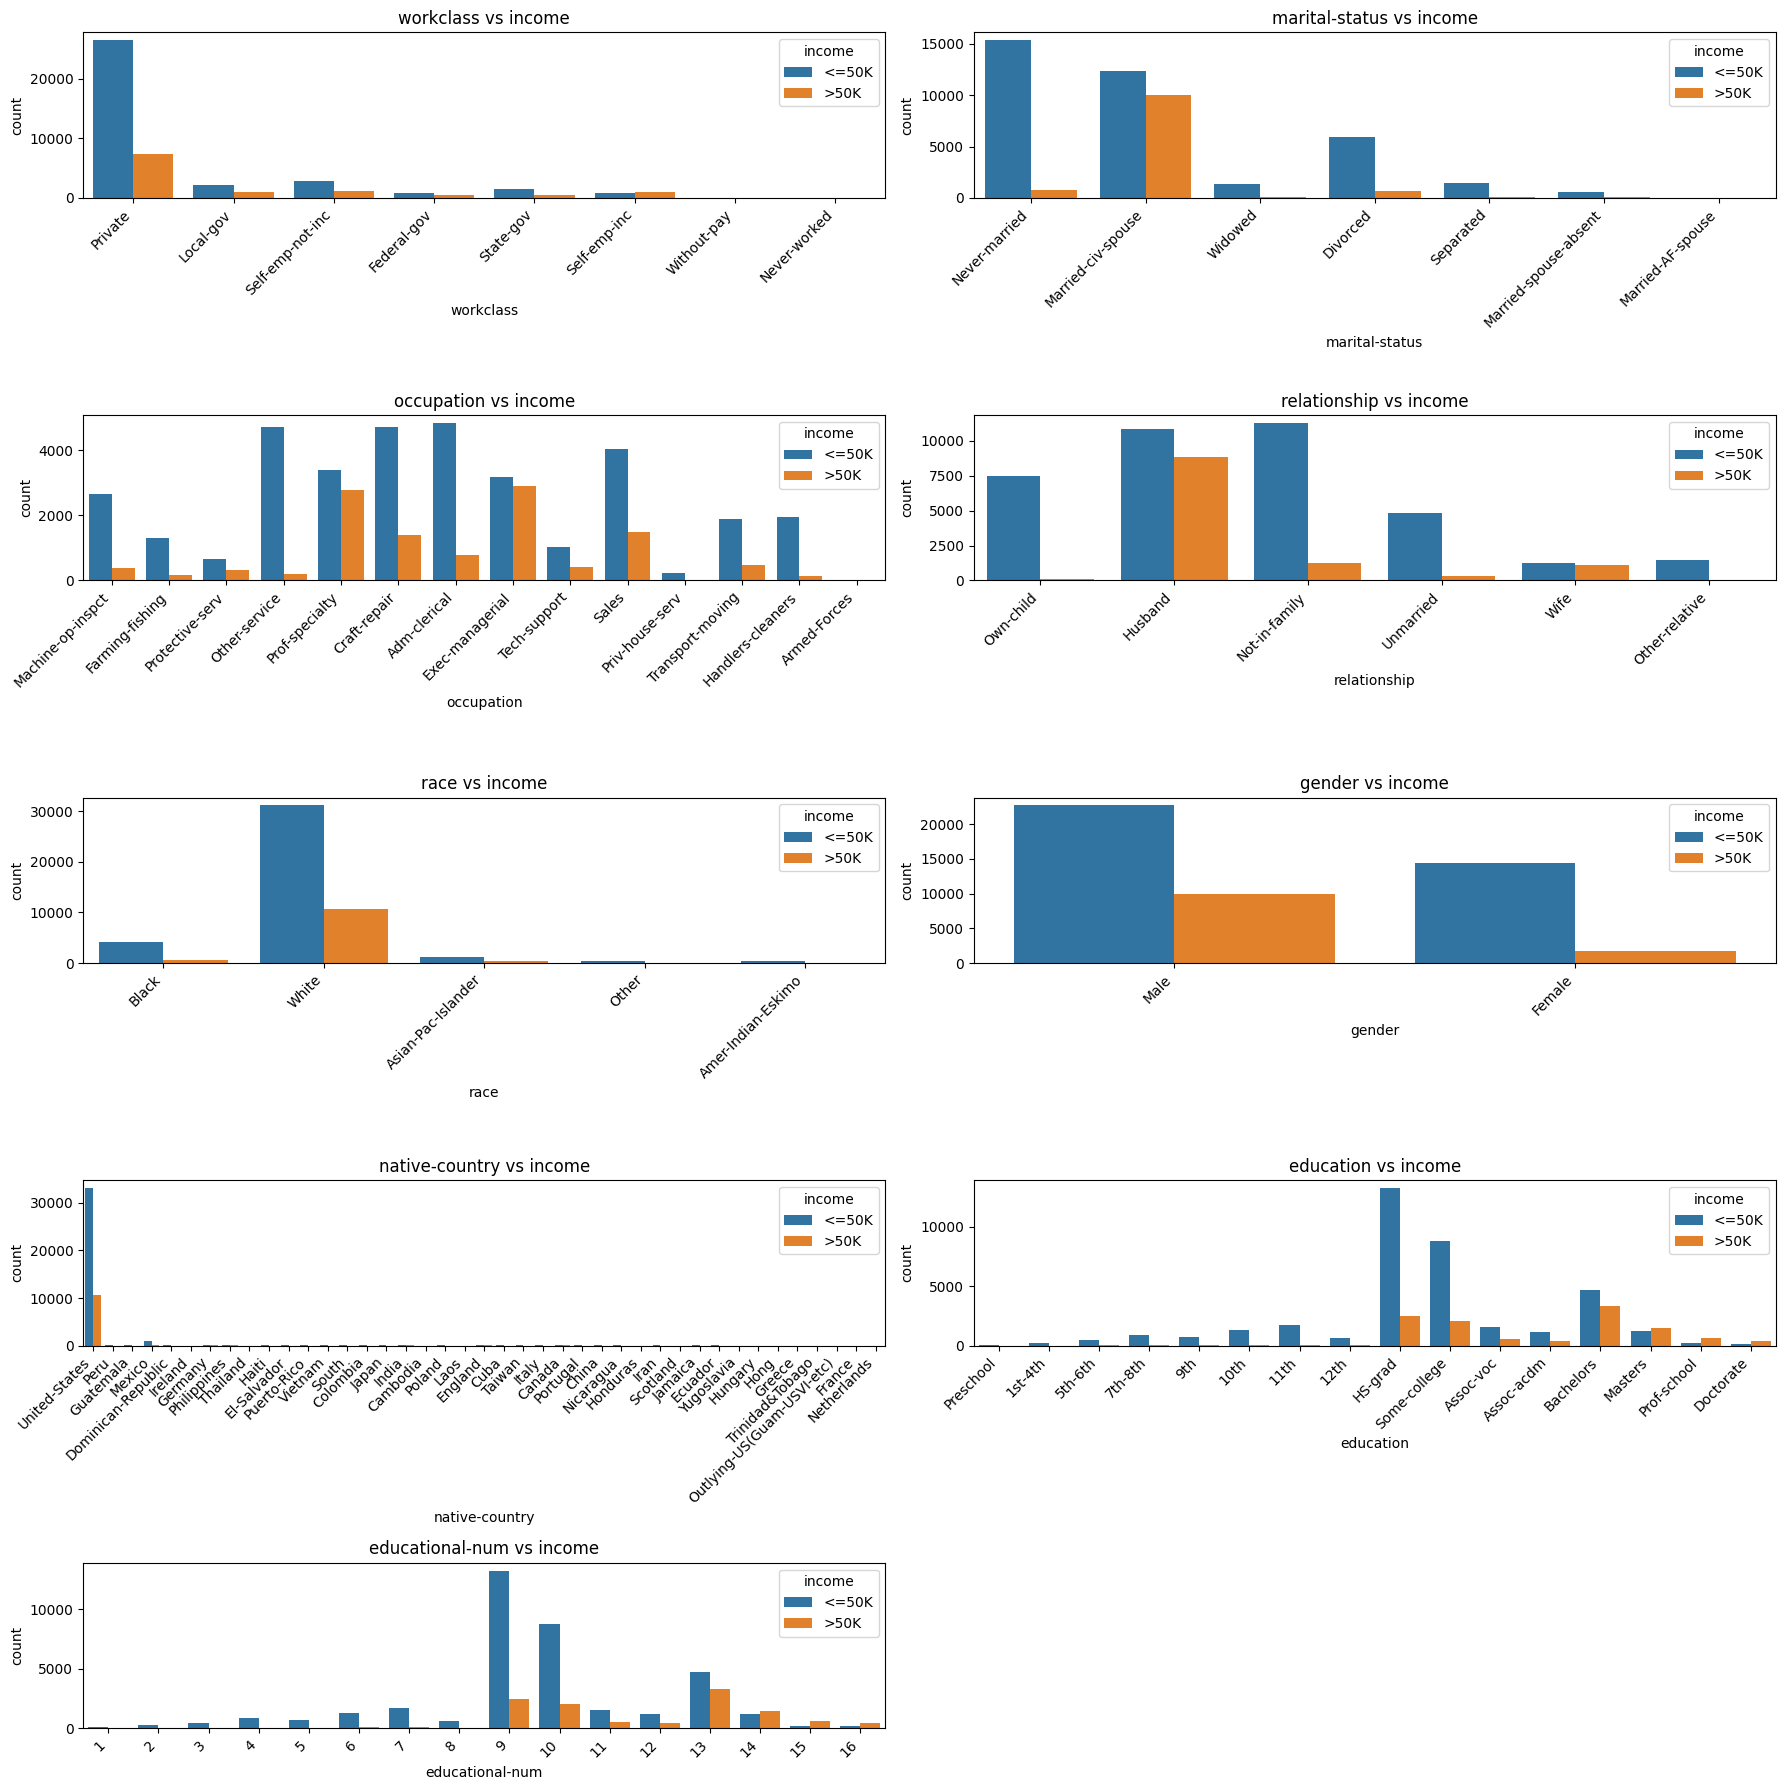

In [74]:
category_orders = {
    'education': ['Preschool', '1st-4th', '5th-6th', '7th-8th', '9th', '10th', '11th', '12th', 'HS-grad',
                  'Some-college', 'Assoc-voc', 'Assoc-acdm', 'Bachelors', 'Masters', 'Prof-school', 'Doctorate'],
    'educational-num': [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16]
}

features = categorical_cols + ordinal_cols

fig, axes = plt.subplots(5, 2, figsize=(18, 18))
axes = axes.flatten()

for i, col in enumerate(features):

    sns.countplot(
        data=df,
        x=col,
        hue=target,
        order=category_orders.get(col),
        ax=axes[i]
    )

    axes[i].set_title(f'{col} vs income')
    axes[i].tick_params(axis='x', rotation=45)
    for label in axes[i].get_xticklabels():
        label.set_horizontalalignment('right')

# Remove unused subplots
for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

- `Private` is the most common workclass for both income groups.
- `Married-civ-spouse` has many more `>50K` cases than other marital groups.
- `Exec-managerial` and `Prof-specialty` show many high-income cases.
- `Husband` has a high number of `>50K` cases.
- Most records are `White` and `Male`, so raw counts are affected by group size.
- `United-States` strongly dominates `native-country`.
- Higher education levels such as `Bachelors`, `Masters`, `Prof-school`, and `Doctorate` have more `>50K` cases.

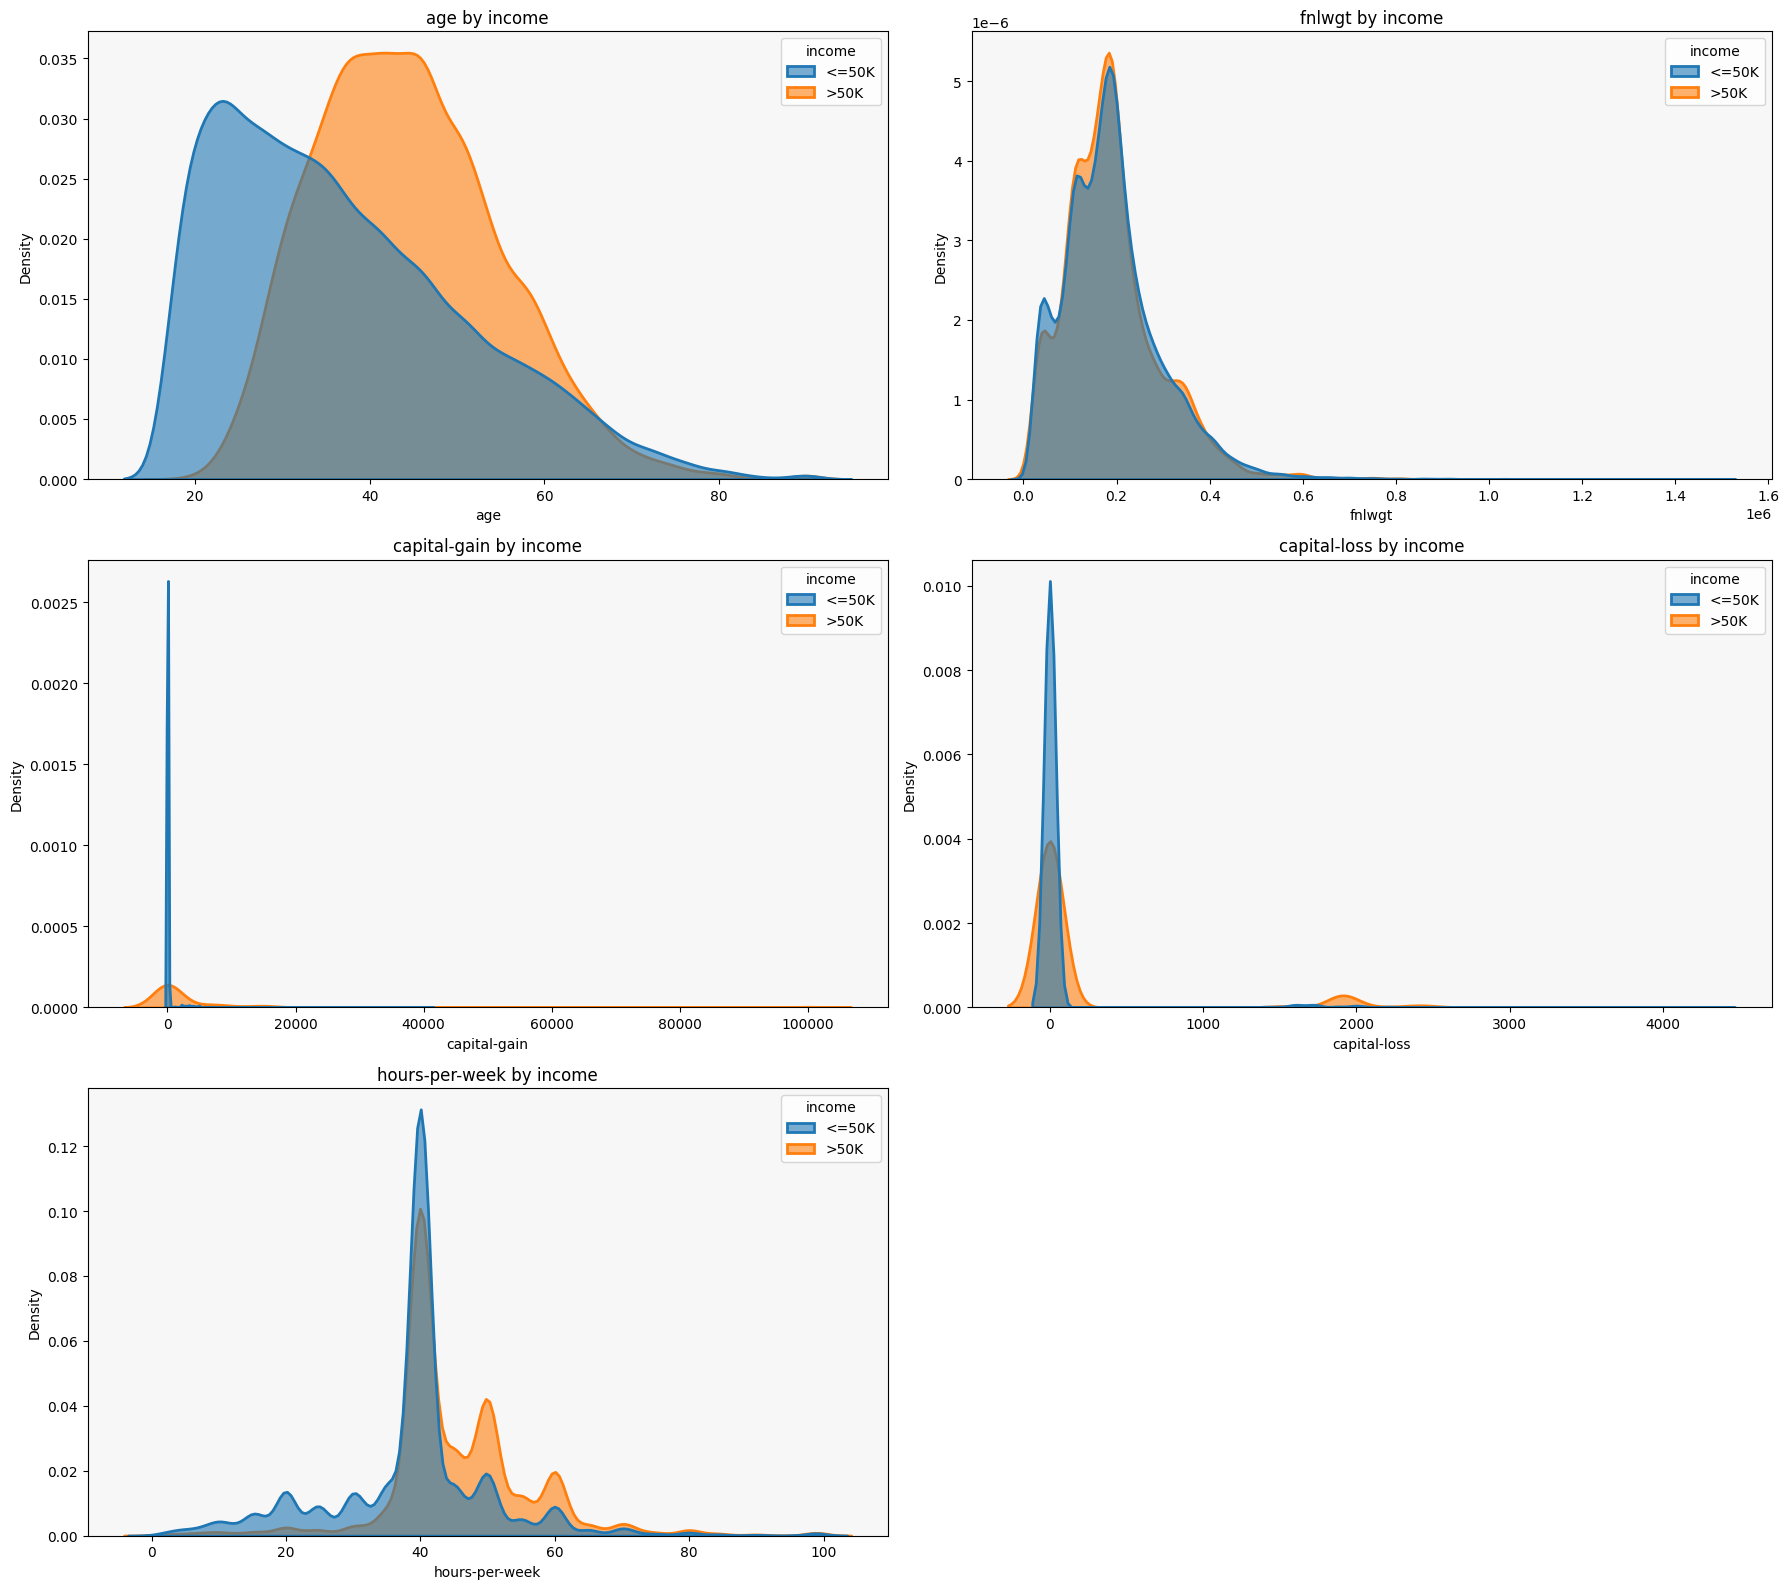

In [75]:
fig, axes = plt.subplots(3, 2, figsize=(18, 16))
axes = axes.flatten()

for i, feature in enumerate(numerical_cols):

    subset = df[[feature, target]].dropna()

    sns.kdeplot(
        data=subset,
        x=feature,
        hue=target,
        common_norm=False,
        fill=True,
        alpha=0.6,
        linewidth=2,
        ax=axes[i]
    )

    axes[i].set_title(f'{feature} by income')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Density')
    axes[i].set_facecolor("#f7f7f7")

# Remove unused subplots
for j in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

- People earning `>50K` are mostly concentrated at older ages, especially around 35–55.
- `fnlwgt` looks very similar for both income groups.
- `capital-gain` and `capital-loss` are mostly 0, but non-zero values appear more often in the `>50K` group.
- People earning `>50K` tend to work more hours per week.
- Around 40 hours per week is the most common value for both groups.

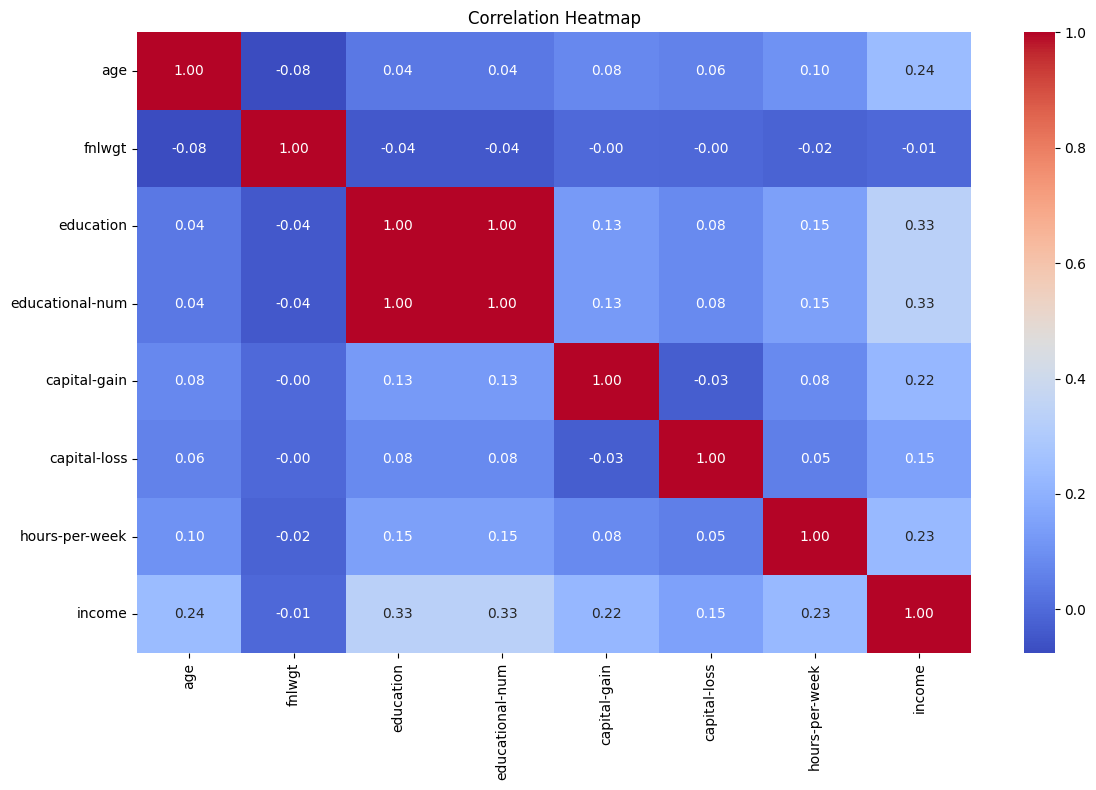

In [76]:
df_corr = df.copy()

# Drop rows with missing categorical values for correlation only
df_corr = df_corr.dropna(
    subset=['workclass', 'occupation', 'native-country']
).reset_index(drop=True)

# Ordinal encode education
education_order = [
    'Preschool', '1st-4th', '5th-6th', '7th-8th',
    '9th', '10th', '11th', '12th',
    'HS-grad', 'Some-college', 'Assoc-voc',
    'Assoc-acdm', 'Bachelors', 'Masters',
    'Prof-school', 'Doctorate'
]

education_encoder = OrdinalEncoder(categories=[education_order])

df_corr[['education']] = education_encoder.fit_transform(
    df_corr[['education']]
)

# Encode target
income_encoder = LabelEncoder()

df_corr['income'] = income_encoder.fit_transform(
    df_corr['income']
)

# Drop nominal categorical columns
df_corr = df_corr.drop(columns=[
    'workclass',
    'marital-status',
    'occupation',
    'relationship',
    'race',
    'gender',
    'native-country'
])

corr = df_corr.corr(numeric_only=True)

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.tight_layout()

- `education` and `educational-num` have a correlation of `1.00`, so they contain the same information.
- `education` / `educational-num` has the strongest correlation with `income` at about `0.33`.
- `age`, `hours-per-week`, and `capital-gain` also have positive relationships with `income`.
- `capital-loss` has a weaker positive relationship with `income`.
- `fnlwgt` has almost no relationship with `income`.
- No strong multicollinearity appears between the other numerical features.

## Preprocessing

In [110]:
# split data
y = df[target]
X = df.drop(columns=[target, 'educational-num'])

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, stratify=y)

# encode target for xgb
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# ordinal category orders
education_order = ['Preschool', '1st-4th', '5th-6th', '7th-8th', '9th', '10th', '11th', '12th', 'HS-grad',
                  'Some-college', 'Assoc-voc', 'Assoc-acdm', 'Bachelors', 'Masters', 'Prof-school', 'Doctorate']

ord_tuple = ('Ordinal', OrdinalEncoder(categories=[education_order]), ['education'])

# Nominal
ohe_cols = (X_train.select_dtypes(include='object').columns.drop('education'))

ohe_pipe = make_pipeline(
  SimpleImputer(strategy='constant', fill_value='MISSING'),
  OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first'))

ohe_tuple = ('Categorical', ohe_pipe , ohe_cols)

# Numbers
skewed_cols = ['fnlwgt', 'capital-gain', 'capital-loss']
num_cols = (X_train.select_dtypes(include='number').columns.drop(skewed_cols))

num_tuple= ('Numeric', StandardScaler(), num_cols)

skewed_pipe = make_pipeline(
    FunctionTransformer(np.log1p, feature_names_out='one-to-one'),
    StandardScaler())

skewed_tuple=('Skewed Numeric', skewed_pipe, skewed_cols)

preprocessor = ColumnTransformer(
    [num_tuple, skewed_tuple, ord_tuple, ohe_tuple],
    verbose_feature_names_out=False)

In [93]:
# Model Evaluation Function
def classification_metrics(y_true,y_pred,label='',output_dict=False,figsize=(8, 4),normalize='true',cmap='Blues',colorbar=False):
    # Get the classification report
    report = classification_report(y_true, y_pred)

    # Print header and report
    header = "--" * 70
    print(header, f" Classification Metrics: {label}", header, sep='\n')
    print(report)

    # CONFUSION MATRICES SUBPLOTS
    fig, axes = plt.subplots(ncols=2, figsize=figsize)

    # Create a confusion matrix of raw counts
    ConfusionMatrixDisplay.from_predictions(y_true,y_pred,normalize=None,cmap='gist_gray',colorbar=colorbar,ax=axes[0])
    axes[0].set_title("Raw Counts")

    # Create a normalized confusion matrix
    ConfusionMatrixDisplay.from_predictions(y_true,y_pred,normalize=normalize,cmap=cmap,colorbar=colorbar,ax=axes[1] )
    axes[1].set_title("Normalized Confusion Matrix")

    # Adjust layout and show figure
    fig.tight_layout()
    plt.show()

    # Return dictionary version of classification_report
    if output_dict == True:
        report_dict = classification_report(
            y_true,
            y_pred,
            output_dict=True
        )
        return report_dict
def evaluate_classification(model,X_train,y_train,X_test,y_test,figsize=(6, 4),normalize='true',output_dict=False,cmap_train="Blues",cmap_test="Reds",colorbar=False):
    # Get predictions for training data
    y_train_pred = model.predict(X_train)

    # Call the helper function to obtain classification metrics for training data
    results_train = classification_metrics(y_train,y_train_pred,output_dict=True,figsize=figsize,colorbar=colorbar,cmap=cmap_train,label='Training Data')

    print()

    # Get predictions for test data
    y_test_pred = model.predict(X_test)

    # Call the helper function to obtain classification metrics for test data
    results_test = classification_metrics( y_test, y_test_pred,output_dict=True,figsize=figsize,colorbar=colorbar,cmap=cmap_test,label='Test Data')

    if output_dict == True:
        # Store results in a dictionary if output_dict is True
        results_dict = {
            'train': results_train,
            'test': results_test
        }
        return results_dict

## Model: KNN

--------------------------------------------------------------------------------------------------------------------------------------------
 Classification Metrics: Training Data
--------------------------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K       0.91      0.93      0.92     27831
        >50K       0.77      0.72      0.74      8761

    accuracy                           0.88     36592
   macro avg       0.84      0.83      0.83     36592
weighted avg       0.88      0.88      0.88     36592



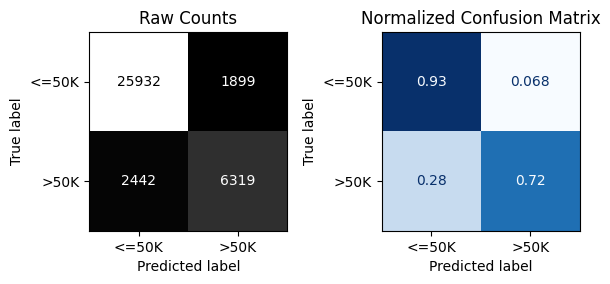


--------------------------------------------------------------------------------------------------------------------------------------------
 Classification Metrics: Test Data
--------------------------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K       0.89      0.90      0.89      9278
        >50K       0.66      0.63      0.64      2920

    accuracy                           0.83     12198
   macro avg       0.77      0.76      0.77     12198
weighted avg       0.83      0.83      0.83     12198



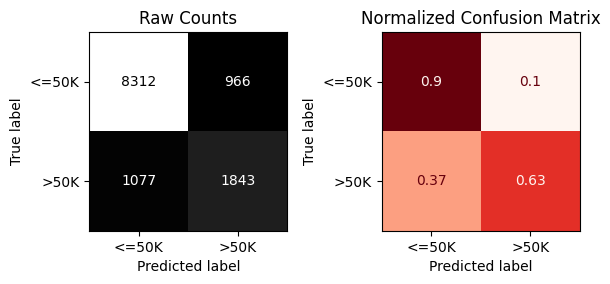

In [94]:
# default KNN
knn= KNeighborsClassifier()

knn_pipe=make_pipeline(preprocessor, knn)
knn_pipe.fit(X_train, y_train)

# evaluate
evaluate_classification(knn_pipe, X_train, y_train, X_test, y_test)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
{'kneighborsclassifier__metric': 'manhattan', 'kneighborsclassifier__n_neighbors': 51, 'kneighborsclassifier__weights': 'uniform'}
0.7814731407744618
--------------------------------------------------------------------------------------------------------------------------------------------
 Classification Metrics: Training Data
--------------------------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K       0.89      0.92      0.91     27831
        >50K       0.71      0.65      0.68      8761

    accuracy                           0.85     36592
   macro avg       0.80      0.78      0.79     36592
weighted avg       0.85      0.85      0.85     36592



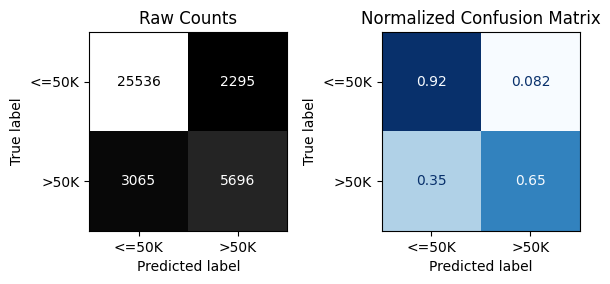


--------------------------------------------------------------------------------------------------------------------------------------------
 Classification Metrics: Test Data
--------------------------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K       0.89      0.91      0.90      9278
        >50K       0.70      0.64      0.67      2920

    accuracy                           0.85     12198
   macro avg       0.79      0.78      0.78     12198
weighted avg       0.84      0.85      0.85     12198



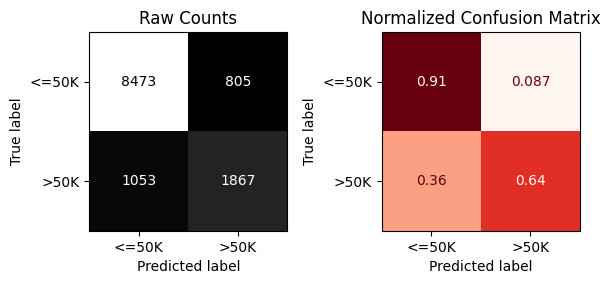

In [101]:
# nneighbors_list = [25, 31, 35, 41, 51]

# params = {
#     'kneighborsclassifier__n_neighbors': nneighbors_list,
#     'kneighborsclassifier__weights': ['uniform', 'distance'],
#     'kneighborsclassifier__metric': ['manhattan']
# }

# gridsearch = GridSearchCV(
#     knn_pipe,
#     params,
#     scoring='f1_macro',
#     cv=3,
#     n_jobs=-1,
#     verbose=1
# )

# gridsearch.fit(X_train, y_train)

# print(gridsearch.best_params_)
# print(gridsearch.best_score_)

# best_knn = gridsearch.best_estimator_

# evaluate_classification(
#     best_knn,
#     X_train,
#     y_train,
#     X_test,
#     y_test
# )

--------------------------------------------------------------------------------------------------------------------------------------------
 Classification Metrics: Training Data
--------------------------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K       0.89      0.92      0.91     27831
        >50K       0.71      0.65      0.68      8761

    accuracy                           0.85     36592
   macro avg       0.80      0.78      0.79     36592
weighted avg       0.85      0.85      0.85     36592



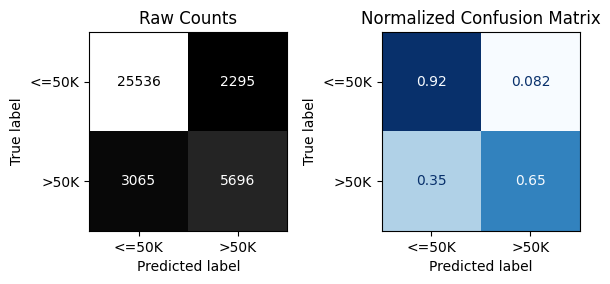


--------------------------------------------------------------------------------------------------------------------------------------------
 Classification Metrics: Test Data
--------------------------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K       0.89      0.91      0.90      9278
        >50K       0.70      0.64      0.67      2920

    accuracy                           0.85     12198
   macro avg       0.79      0.78      0.78     12198
weighted avg       0.84      0.85      0.85     12198



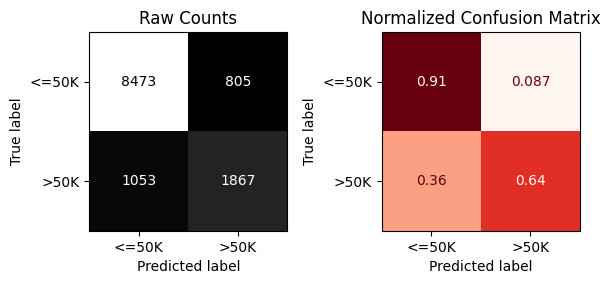

In [102]:
# tuned KNN
knn= KNeighborsClassifier(metric='manhattan',
                          n_neighbors= 51,
                          weights= 'uniform')

knn_pipe=make_pipeline(preprocessor, knn)
knn_pipe.fit(X_train, y_train)

# evaluate
evaluate_classification(knn_pipe, X_train, y_train, X_test, y_test)

## Model: Random Forest

--------------------------------------------------------------------------------------------------------------------------------------------
 Classification Metrics: Training Data
--------------------------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K       1.00      1.00      1.00     27831
        >50K       1.00      1.00      1.00      8761

    accuracy                           1.00     36592
   macro avg       1.00      1.00      1.00     36592
weighted avg       1.00      1.00      1.00     36592



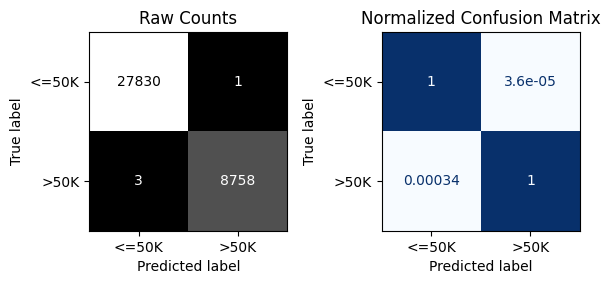


--------------------------------------------------------------------------------------------------------------------------------------------
 Classification Metrics: Test Data
--------------------------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.91      9278
        >50K       0.74      0.61      0.67      2920

    accuracy                           0.86     12198
   macro avg       0.81      0.77      0.79     12198
weighted avg       0.85      0.86      0.85     12198



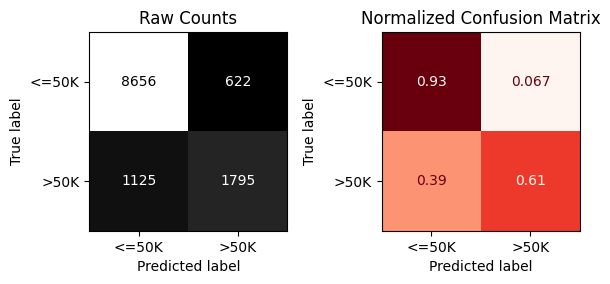

In [100]:
# default model
rf = RandomForestClassifier(random_state=42)
rf_pipe = make_pipeline(preprocessor, rf)

rf_pipe.fit(X_train, y_train)

evaluate_classification(rf_pipe,X_train, y_train, X_test, y_test)

Fitting 3 folds for each of 16 candidates, totalling 48 fits

Best Parameters:
{'randomforestclassifier__class_weight': 'balanced_subsample', 'randomforestclassifier__max_depth': 30, 'randomforestclassifier__max_features': 'sqrt', 'randomforestclassifier__min_samples_leaf': 1, 'randomforestclassifier__min_samples_split': 5, 'randomforestclassifier__n_estimators': 200}

Best CV Macro F1:
0.8032922042690939
--------------------------------------------------------------------------------------------------------------------------------------------
 Classification Metrics: Training Data
--------------------------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K       0.99      0.91      0.95     27831
        >50K       0.78      0.97      0.86      8761

    accuracy                           0.93     36592
   macro avg       0.88      0.94      0.91     3659

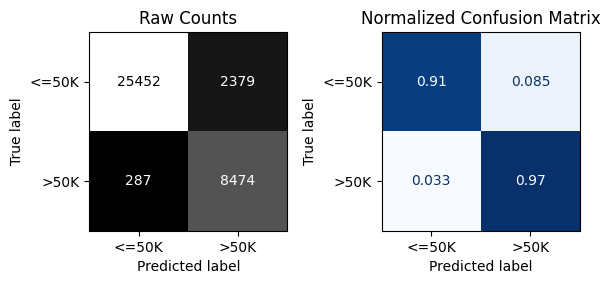


--------------------------------------------------------------------------------------------------------------------------------------------
 Classification Metrics: Test Data
--------------------------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K       0.93      0.87      0.90      9278
        >50K       0.65      0.78      0.71      2920

    accuracy                           0.85     12198
   macro avg       0.79      0.82      0.80     12198
weighted avg       0.86      0.85      0.85     12198



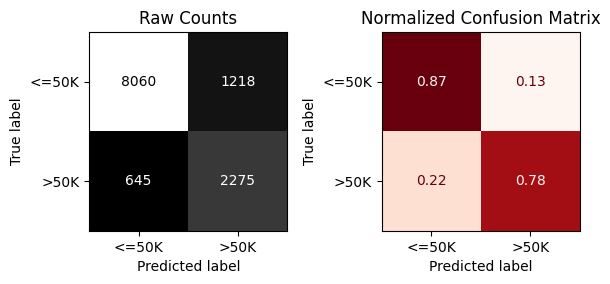

In [105]:
# params = {
#     'randomforestclassifier__n_estimators': [200],
#     'randomforestclassifier__max_depth': [20, 25, 30, None],
#     'randomforestclassifier__min_samples_split': [3, 5],
#     'randomforestclassifier__min_samples_leaf': [1, 2],
#     'randomforestclassifier__max_features': ['sqrt'],
#     'randomforestclassifier__class_weight': ['balanced_subsample']
# }

# # Grid Search
# gridsearch = GridSearchCV(
#     rf_pipe,
#     params,
#     scoring='f1_macro',
#     cv=3,
#     n_jobs=-1,
#     verbose=1
# )

# # Train
# gridsearch.fit(X_train, y_train)

# # Best parameters
# print("\nBest Parameters:")
# print(gridsearch.best_params_)

# print("\nBest CV Macro F1:")
# print(gridsearch.best_score_)

# # Best model
# best_rf = gridsearch.best_estimator_

# # Evaluate
# evaluate_classification(best_rf, X_train, y_train, X_test, y_test)

--------------------------------------------------------------------------------------------------------------------------------------------
 Classification Metrics: Training Data
--------------------------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K       0.99      0.91      0.95     27831
        >50K       0.78      0.97      0.86      8761

    accuracy                           0.93     36592
   macro avg       0.88      0.94      0.91     36592
weighted avg       0.94      0.93      0.93     36592



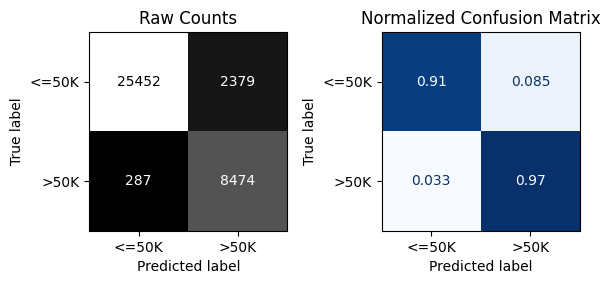


--------------------------------------------------------------------------------------------------------------------------------------------
 Classification Metrics: Test Data
--------------------------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K       0.93      0.87      0.90      9278
        >50K       0.65      0.78      0.71      2920

    accuracy                           0.85     12198
   macro avg       0.79      0.82      0.80     12198
weighted avg       0.86      0.85      0.85     12198



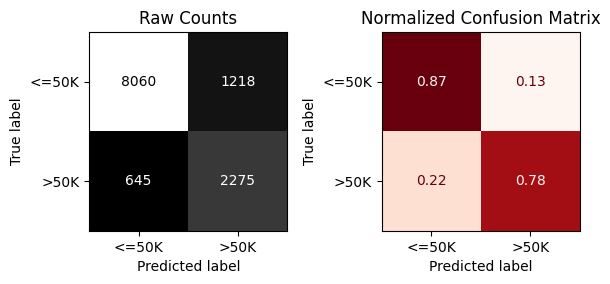

In [106]:
# tuned rf model
rf = RandomForestClassifier(random_state=42,
                            class_weight= 'balanced_subsample',
                            max_depth= 30,
                            max_features= 'sqrt',
                            min_samples_leaf= 1,
                            min_samples_split= 5,
                            n_estimators= 200)
rf_pipe = make_pipeline(preprocessor, rf)

rf_pipe.fit(X_train, y_train)

evaluate_classification(rf_pipe,X_train, y_train, X_test, y_test)

## Model: XGBoost

--------------------------------------------------------------------------------------------------------------------------------------------
 Classification Metrics: Training Data
--------------------------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.91      0.96      0.93     27831
           1       0.84      0.71      0.77      8761

    accuracy                           0.90     36592
   macro avg       0.87      0.83      0.85     36592
weighted avg       0.89      0.90      0.89     36592



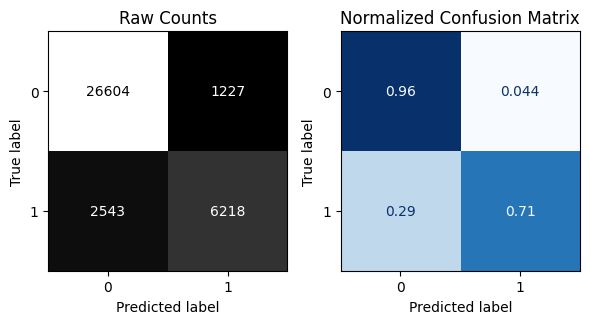


--------------------------------------------------------------------------------------------------------------------------------------------
 Classification Metrics: Test Data
--------------------------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      9278
           1       0.78      0.65      0.71      2920

    accuracy                           0.87     12198
   macro avg       0.84      0.80      0.81     12198
weighted avg       0.87      0.87      0.87     12198



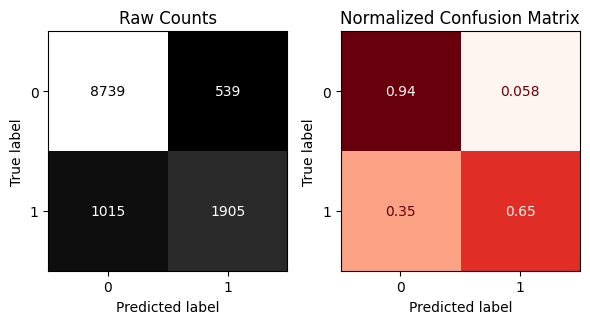

In [113]:
# default xgb model
xgb= XGBClassifier(random_state=42)
xgb_pipe = make_pipeline(preprocessor, xgb)

xgb_pipe.fit(X_train, y_train_encoded)

evaluate_classification(
    xgb_pipe,
    X_train, y_train_encoded,
    X_test, y_test_encoded
)

Fitting 3 folds for each of 48 candidates, totalling 144 fits

Best Parameters:
{'xgbclassifier__colsample_bytree': 0.8, 'xgbclassifier__learning_rate': 0.1, 'xgbclassifier__max_depth': 5, 'xgbclassifier__n_estimators': 200, 'xgbclassifier__subsample': 0.8}

Best CV Score:
0.8140679561739209
--------------------------------------------------------------------------------------------------------------------------------------------
 Classification Metrics: Training Data
--------------------------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.90      0.95      0.93     27831
           1       0.81      0.68      0.74      8761

    accuracy                           0.88     36592
   macro avg       0.86      0.81      0.83     36592
weighted avg       0.88      0.88      0.88     36592



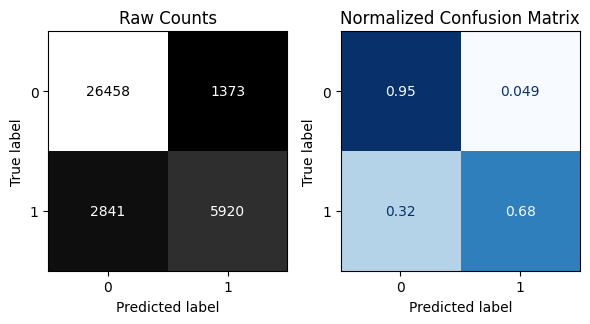


--------------------------------------------------------------------------------------------------------------------------------------------
 Classification Metrics: Test Data
--------------------------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      9278
           1       0.78      0.66      0.71      2920

    accuracy                           0.87     12198
   macro avg       0.84      0.80      0.82     12198
weighted avg       0.87      0.87      0.87     12198



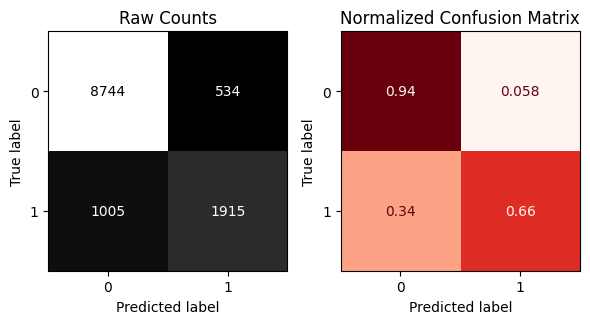

In [114]:
# params = {
#     'xgbclassifier__n_estimators': [100, 200],
#     'xgbclassifier__max_depth': [3, 5, 7],
#     'xgbclassifier__learning_rate': [0.03, 0.1],
#     'xgbclassifier__subsample': [0.8, 1.0],
#     'xgbclassifier__colsample_bytree': [0.8, 1.0]
# }

# gridsearch_xgb = GridSearchCV(
#     xgb_pipe,
#     params,
#     scoring='f1_macro',
#     cv=3,
#     n_jobs=-1,
#     verbose=1
# )

# gridsearch_xgb.fit(X_train, y_train_encoded)

# print("\nBest Parameters:")
# print(gridsearch_xgb.best_params_)

# print("\nBest CV Score:")
# print(gridsearch_xgb.best_score_)

# best_xgb = gridsearch_xgb.best_estimator_

# evaluate_classification(
#     best_xgb,
#     X_train,
#     y_train_encoded,
#     X_test,
#     y_test_encoded
# )

--------------------------------------------------------------------------------------------------------------------------------------------
 Classification Metrics: Training Data
--------------------------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.90      0.95      0.93     27831
           1       0.81      0.68      0.74      8761

    accuracy                           0.88     36592
   macro avg       0.86      0.81      0.83     36592
weighted avg       0.88      0.88      0.88     36592



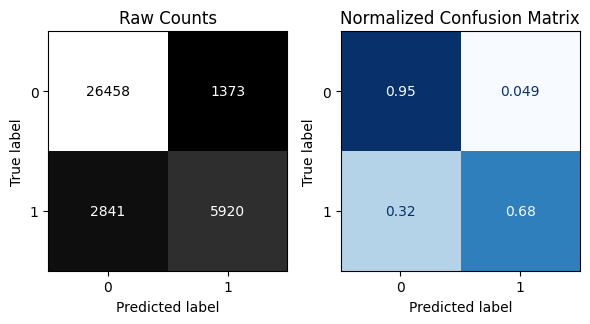


--------------------------------------------------------------------------------------------------------------------------------------------
 Classification Metrics: Test Data
--------------------------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      9278
           1       0.78      0.66      0.71      2920

    accuracy                           0.87     12198
   macro avg       0.84      0.80      0.82     12198
weighted avg       0.87      0.87      0.87     12198



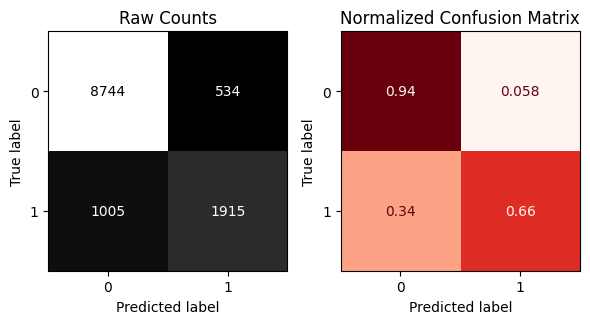

In [115]:
# tuned xgb model
xgb= XGBClassifier(random_state=42,
                   learning_rate=0.1,
                   max_depth=5,
                   n_estimators=200,
                   subsample=0.8,
                   colsample_bytree=0.8)
xgb_pipe = make_pipeline(preprocessor, xgb)

xgb_pipe.fit(X_train, y_train_encoded)

evaluate_classification(
    xgb_pipe,
    X_train, y_train_encoded,
    X_test, y_test_encoded
)

| Model                   | Train Macro F1 | Test Macro F1 | Overfit Gap | Test Accuracy | `<=50K` Recall | `>50K` Recall | `>50K` F1 |
| ----------------------- | -------------: | ------------: | ----------: | ------------: | -------------: | ------------: | --------: |
| **Final KNN**           |           0.79 |          0.78 |    **0.01** |          0.85 |       **0.91** |          0.64 |      0.67 |
| **Final Random Forest** |           0.91 |          0.80 |        0.11 |          0.85 |           0.87 |      **0.78** |  **0.71** |
| **Final XGBoost**       |           0.83 |      **0.82** |    **0.01** |      **0.87** |       **0.94** |          0.66 |  **0.71** |


## Explanatory Data Analysis

In [116]:
# Function to create a color dictionary
def get_color_dict(
    importances,
    color_rest='#006ba4',
    color_top='green',
    top_n=5
):
    # Get the names of the top features
    highlight_feats = (
        importances
        .sort_values(ascending=True)
        .tail(top_n)
        .index
    )

    # Assign green to top features and blue to the remaining features
    colors_dict = {
        col: color_top if col in highlight_feats else color_rest
        for col in importances.index
    }

    return colors_dict

# Function to plot feature importance
def plot_importance_color(
    importances,
    top_n=None,
    figsize=(8, 6),
    color_dict=None
):
    # Sort the importance values
    if top_n is None:
        plot_vals = importances.sort_values()
        title = "All Features - Ranked by Importance"
    else:
        plot_vals = importances.sort_values().tail(top_n)
        title = f"Top {top_n} Most Important Features"

    # Plot using the provided colors
    if color_dict is not None:
        colors = plot_vals.index.map(color_dict)

        ax = plot_vals.plot(
            kind='barh',
            figsize=figsize,
            color=colors
        )

    else:
        ax = plot_vals.plot(
            kind='barh',
            figsize=figsize
        )

    # Labels and title
    ax.set(
        xlabel='Importance',
        ylabel='Feature Names',
        title=title
    )

    return ax

In [118]:
# Calculate permutation importance using unseen test data
r = permutation_importance(
    xgb_pipe,
    X_test,
    y_test_encoded,
    n_repeats=10,
    random_state=42,
    scoring='f1_macro',
    n_jobs=-1
)

# Check the returned results
r.keys()

dict_keys(['importances_mean', 'importances_std', 'importances'])

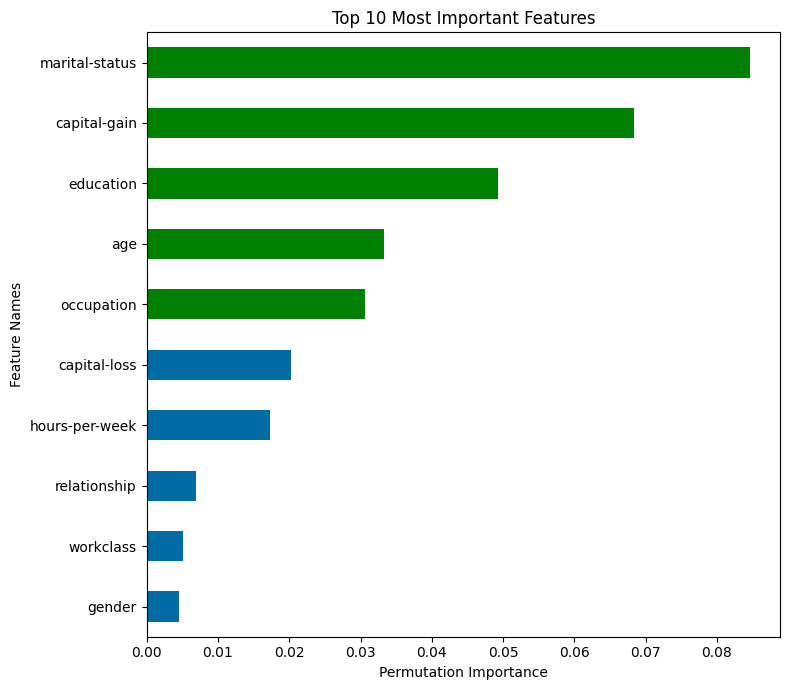

In [119]:
# Convert mean permutation importances into a Series
permutation_importances = pd.Series(
    r['importances_mean'],
    index=X_test.columns,
    name='Permutation Importance'
)

# Sort from highest to lowest
permutation_importances = permutation_importances.sort_values(
    ascending=False
)

colors_top5 = get_color_dict(
    permutation_importances,
    top_n=5
)

ax = plot_importance_color(
    permutation_importances,
    color_dict=colors_top5,
    top_n=10,
    figsize=(8, 7)
)

ax.set_xlabel("Permutation Importance")

plt.tight_layout()


> - `marital-status` and `capital-gain` had the largest impact on the model's **Macro F1**, followed by `education`, `age`, and `occupation`.
> - This aligns with the business goal because these features capture demographic, financial, and employment-related information that can help distinguish between the `<=50K` and `>50K` income groups.
> - Features such as `gender` and `workclass` had a much smaller effect on the model's overall balanced performance.
> - These results show **predictive relationships**, not causal relationships.


    colors = ['#334E68', '#2A9D8F']


In [150]:
def plot_income_by_feature(df, feature, figsize=(10, 5)):
    plot_df = df[[feature, 'income']].dropna().copy()
    income_order = ['<=50K', '>50K']
    colors = ['#415A77', '#2A9D8F']

    custom_orders = {
        'education': ['Preschool', '1st-4th', '5th-6th', '7th-8th', '9th', '10th', '11th', '12th',
                      'HS-grad', 'Some-college', 'Assoc-voc', 'Assoc-acdm', 'Bachelors', 'Masters',
                      'Prof-school', 'Doctorate'],
        'marital-status': ['Never-married', 'Married-civ-spouse', 'Married-AF-spouse',
                           'Married-spouse-absent', 'Separated', 'Divorced', 'Widowed']
    }

    if feature == 'capital-gain':
        positive = plot_df.loc[plot_df[feature] > 0, feature]
        q1, q2 = positive.quantile([1/3, 2/3])
        plot_df['Group'] = pd.cut(
            plot_df[feature],
            bins=[-np.inf, 0, q1, q2, np.inf],
            labels=['Zero', 'Low', 'Medium', 'High']
        )
        order = ['Zero', 'Low', 'Medium', 'High']

    elif pd.api.types.is_numeric_dtype(plot_df[feature]):
        plot_df['Group'] = pd.qcut(
            plot_df[feature].rank(method='first'),
            q=4,
            labels=['Low', 'Medium', 'High', 'Very High']
        )
        order = ['Low', 'Medium', 'High', 'Very High']

    else:
        order = custom_orders.get(feature, plot_df[feature].value_counts().index.tolist())
        order = [x for x in order if x in plot_df[feature].unique()]
        plot_df['Group'] = pd.Categorical(plot_df[feature], categories=order, ordered=True)

    income_percent = pd.crosstab(
        plot_df['Group'], plot_df['income'], normalize='index'
    ).mul(100).reindex(index=order, columns=income_order, fill_value=0)

    fig, ax = plt.subplots(figsize=figsize, dpi=120)
    income_percent.plot(kind='bar', stacked=True, width=0.72, color=colors, ax=ax, zorder=3)

    for container in ax.containers:
        labels = [f'{v:.1f}%' if v >= 4 else '' for v in container.datavalues]
        ax.bar_label(container, labels=labels, label_type='center',
                     fontsize=9, color='white', fontweight='bold')

    ax.set_title(
        f'Income Distribution Across {feature.replace("-", " ").title()}',
        fontsize=15, fontweight='bold', pad=14
    )
    ax.set_xlabel(feature.replace('-', ' ').title(), fontsize=11)
    ax.set_ylabel('Percentage of Individuals', fontsize=11)
    ax.set_ylim(0, 100)

    rotation = 35 if feature in ['education', 'marital-status'] else 0
    ax.tick_params(axis='x', rotation=rotation, labelsize=9)

    if rotation:
        for label in ax.get_xticklabels():
            label.set_horizontalalignment('right')

    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.25, zorder=0)
    ax.set_axisbelow(True)
    ax.legend(
        title='Income',
        labels=['≤50K', '>50K'],
        bbox_to_anchor=(1.01, 1),
        loc='upper left',
        frameon=False
    )

    plt.tight_layout()
    plt.show()

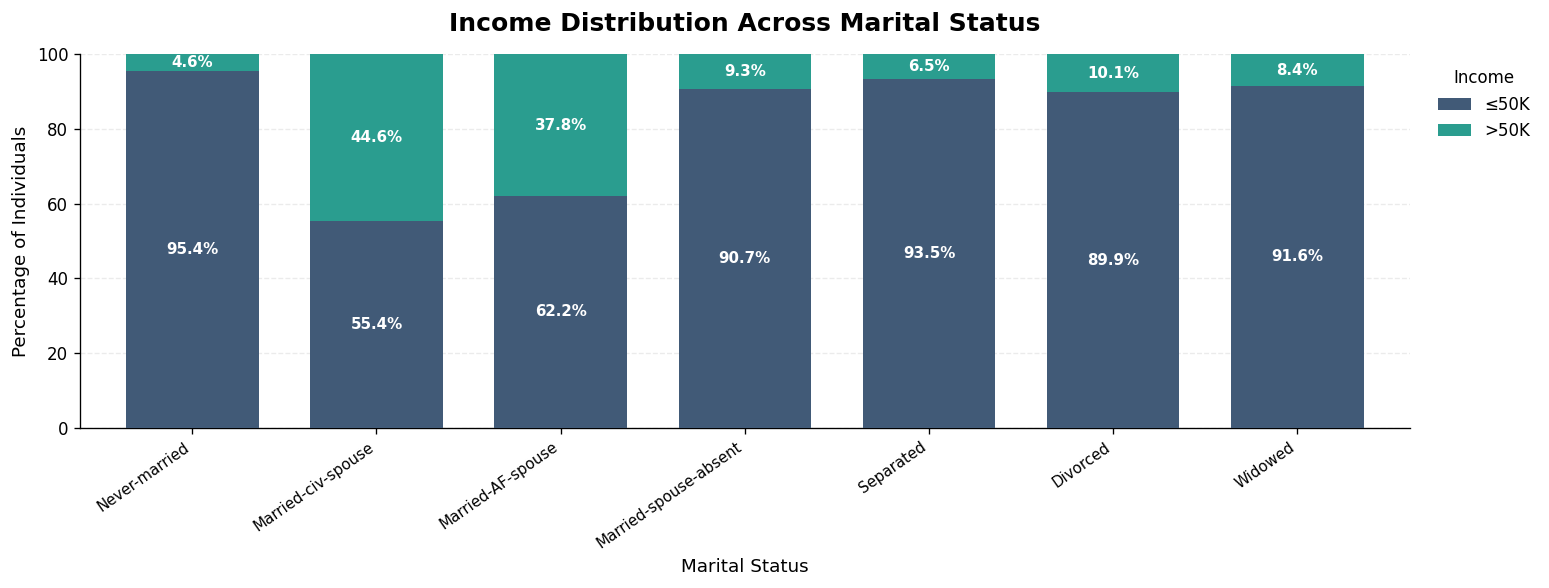

In [152]:
plot_income_by_feature(df, 'marital-status', figsize=(13, 5))

> - `Married-civ-spouse` and `Married-AF-spouse` have much higher proportions of individuals earning `>50K`, while most other marital-status groups are strongly concentrated in `<=50K`.
> - This supports `marital-status` being the most important feature in permutation importance, since it helps the model distinguish between income groups.
> - For the use case, this suggests household and marital characteristics contain useful information for income segmentation, although the relationship should not be interpreted as causal.

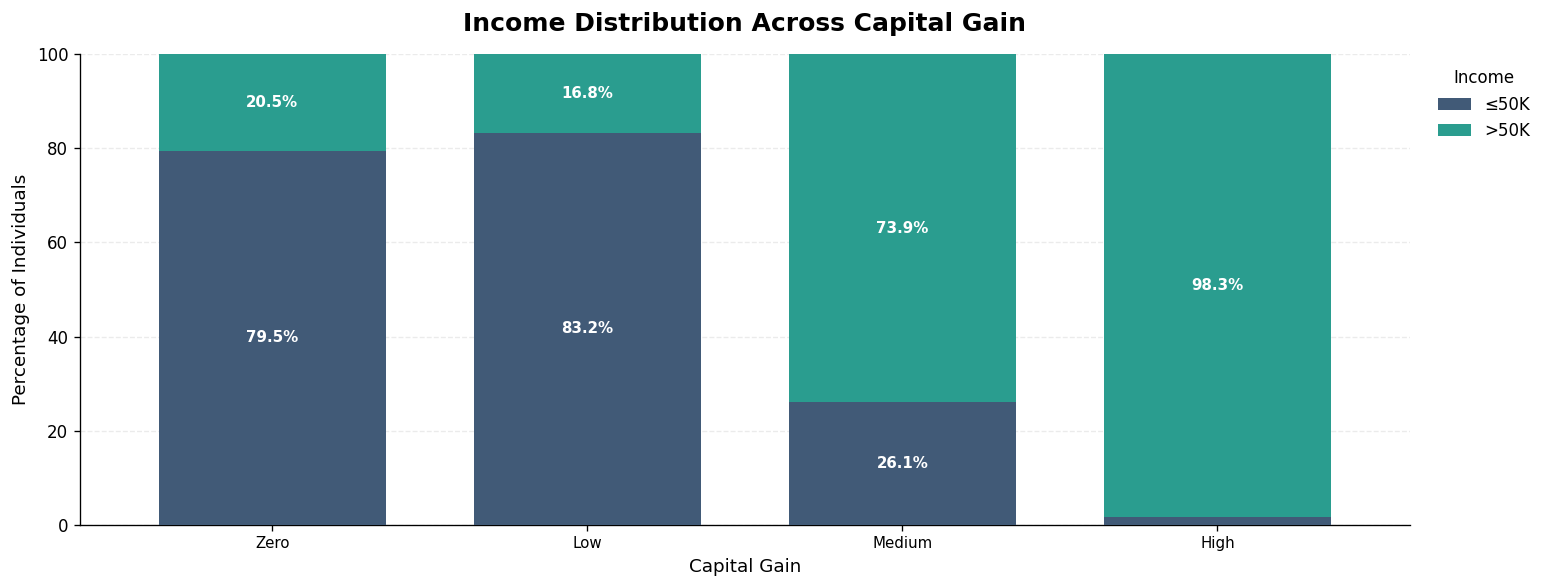

In [153]:
plot_income_by_feature(df, 'capital-gain', figsize=(13, 5))

> - Income level changes strongly as `capital-gain` increases. Around 74% of the medium group and 98% of the high group earn `>50K`, compared with only about 20% among those with no capital gain.
> - This makes `capital-gain` highly useful for identifying higher-income individuals and explains why it ranked second in permutation importance.
> - For income segmentation and economic analysis, capital gain provides a strong financial signal that can help separate the two income groups.

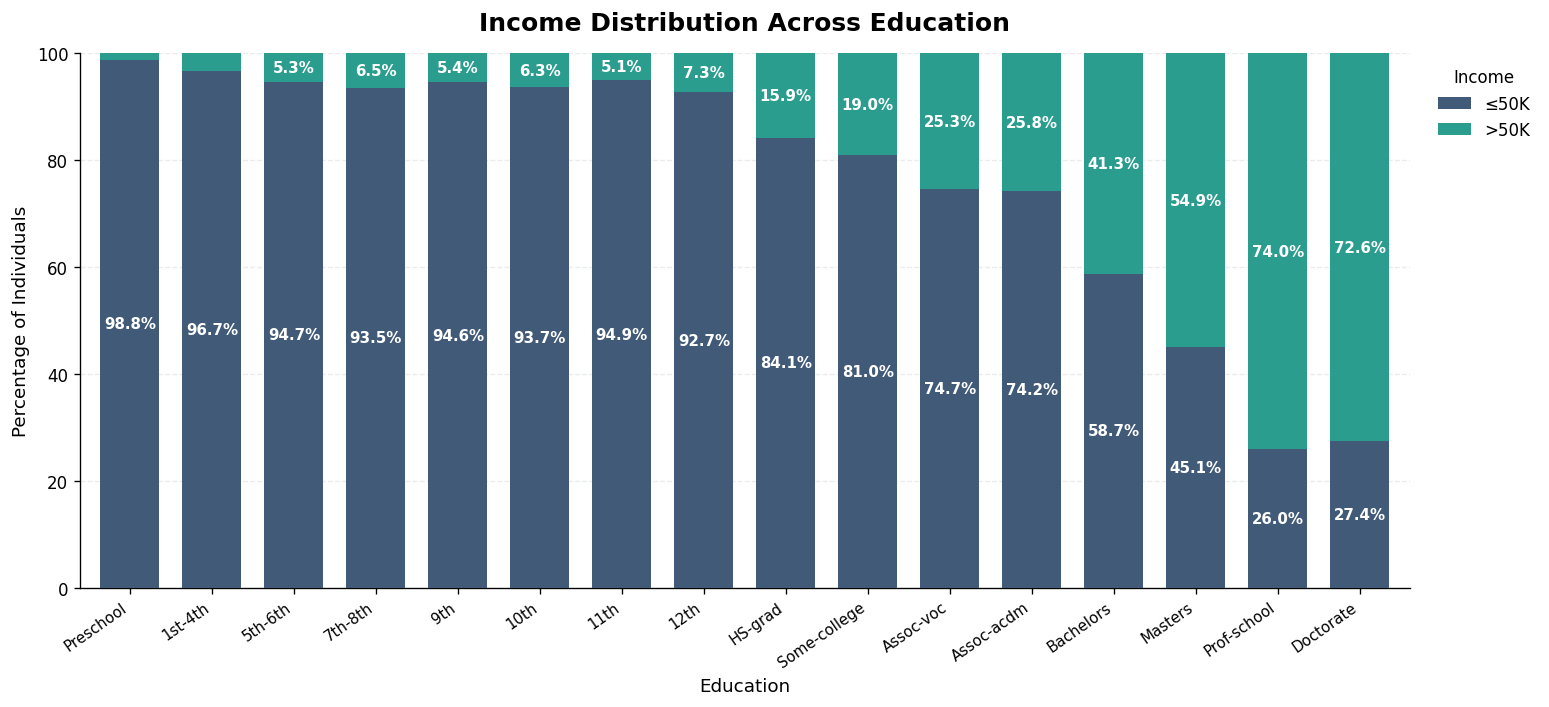

In [151]:
plot_income_by_feature(df, 'education', figsize=(13, 6))

> - The proportion earning `>50K` generally increases with education level. Only a small percentage of individuals with lower education levels earn `>50K`, compared with about 41% of those with a Bachelor's degree, 55% with a Master's, and over 70% with professional or doctoral education.
> - This supports `education` being one of the model's most important predictors and shows a clear relationship between education level and income group.
> - For the use case, education can help identify population segments with different income patterns and support broader economic or workforce analysis.

## Feature Engineering

### KMeans

## Neural Networks